In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "/content/synthetic_fraud_dataset.csv"
df = pd.read_csv(file_path)
print("Dataset loaded successfully")

Dataset loaded successfully


In [ ]:
display(df.head())

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [ ]:
# Generate UPI IDs (from previous notebook state)
banks = ["icici", "sbi", "hdfc", "axis", "kotak", "pnb", "boi"]
base_names = df['Merchant_Category'].str.replace(" ", "").str.lower()
numbers = np.random.randint(100, 999, size=len(df))
bank_names = np.random.choice(banks, size=len(df))
df['Merchant_UPI_ID'] = base_names + numbers.astype(str) + "@" + bank_names

# Reorder columns → insert after Merchant_Category
cols = df.columns.tolist()
insert_at = cols.index("Merchant_Category") + 1
cols = cols[:insert_at] + ["Merchant_UPI_ID"] + cols[insert_at:-1] + [cols[-1]]
df = df[cols]

# Drop duplicate columns if any
df = df.loc[:, ~df.columns.duplicated()]

print("Shape of dataset:", df.shape)
print("\nColumn names:\n", df.columns)

display(df.head())

Shape of dataset: (50000, 22)

Column names:
 Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Timestamp', 'Account_Balance', 'Device_Type', 'Location',
       'Merchant_Category', 'Merchant_UPI_ID', 'IP_Address_Flag',
       'Previous_Fraudulent_Activity', 'Daily_Transaction_Count',
       'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Type',
       'Card_Age', 'Transaction_Distance', 'Authentication_Method',
       'Risk_Score', 'Is_Weekend', 'Fraud_Label'],
      dtype='object')


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,Merchant_UPI_ID,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,travel660@axis,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,clothing807@kotak,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,restaurants747@kotak,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,clothing592@sbi,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,electronics547@pnb,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [ ]:
# Data Inspection and Exploration
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  object 
 4   Timestamp                     50000 non-null  object 
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  object 
 7   Location                      50000 non-null  object 
 8   Merchant_Category             50000 non-null  object 
 9   Merchant_UPI_ID               50000 non-null  object 
 10  IP_Address_Flag               50000 non-null  int64  
 11  Previous_Fraudulent_Activity  50000 non-null  int64  
 12  Daily_Transaction_Count       50000 non-null 

In [ ]:
print("\nDataset describe:")
df.describe()


Dataset describe:


,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,99.411012,50294.065981,0.05020,0.098400,7.485240,255.271924,2.003540,119.999940,2499.164155,0.501556,0.299640,0.321340
std,98.687292,28760.458557,0.21836,0.297858,4.039637,141.382279,1.414273,68.985817,1442.013834,0.287774,0.458105,0.466996
min,0.000000,500.480000,0.00000,0.000000,1.000000,10.000000,0.000000,1.000000,0.250000,0.000100,0.000000,0.000000
25%,28.677500,25355.995000,0.00000,0.000000,4.000000,132.087500,1.000000,60.000000,1256.497500,0.254000,0.000000,0.000000
50%,69.660000,50384.430000,0.00000,0.000000,7.000000,256.085000,2.000000,120.000000,2490.785000,0.502250,0.000000,0.000000
75%,138.852500,75115.135000,0.00000,0.000000,11.000000,378.032500,3.000000,180.000000,3746.395000,0.749525,1.000000,1.000000
max,1174.140000,99998.310000,1.00000,1.000000,14.000000,500.000000,4.000000,239.000000,4999.930000,1.000000,1.000000,1.000000


In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Transaction_ID                  0
User_ID                         0
Transaction_Amount              0
Transaction_Type                0
Timestamp                       0
Account_Balance                 0
Device_Type                     0
Location                        0
Merchant_Category               0
Merchant_UPI_ID                 0
IP_Address_Flag                 0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Avg_Transaction_Amount_7d       0
Failed_Transaction_Count_7d     0
Card_Type                       0
Card_Age                        0
Transaction_Distance            0
Authentication_Method           0
Risk_Score                      0
Is_Weekend                      0
Fraud_Label                     0
dtype: int64


In [ ]:
print("\nFraud vs Safe counts:\n", df['Fraud_Label'].value_counts())
print("\nFraud vs Safe percentage:\n", df['Fraud_Label'].value_counts(normalize=True) * 100)


Fraud vs Safe counts:
 Fraud_Label
0    33933
1    16067
Name: count, dtype: int64

Fraud vs Safe percentage:
 Fraud_Label
0    67.866
1    32.134
Name: proportion, dtype: float64


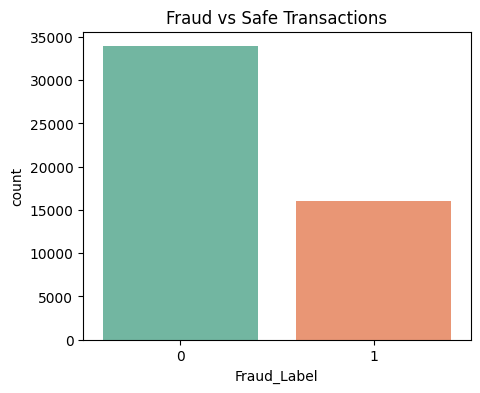

In [ ]:
# Plot target distribution
plt.figure(figsize=(5,4))
sns.countplot(x='Fraud_Label', data=df, palette="Set2", hue='Fraud_Label', legend=False)
plt.title("Fraud vs Safe Transactions")
plt.show()

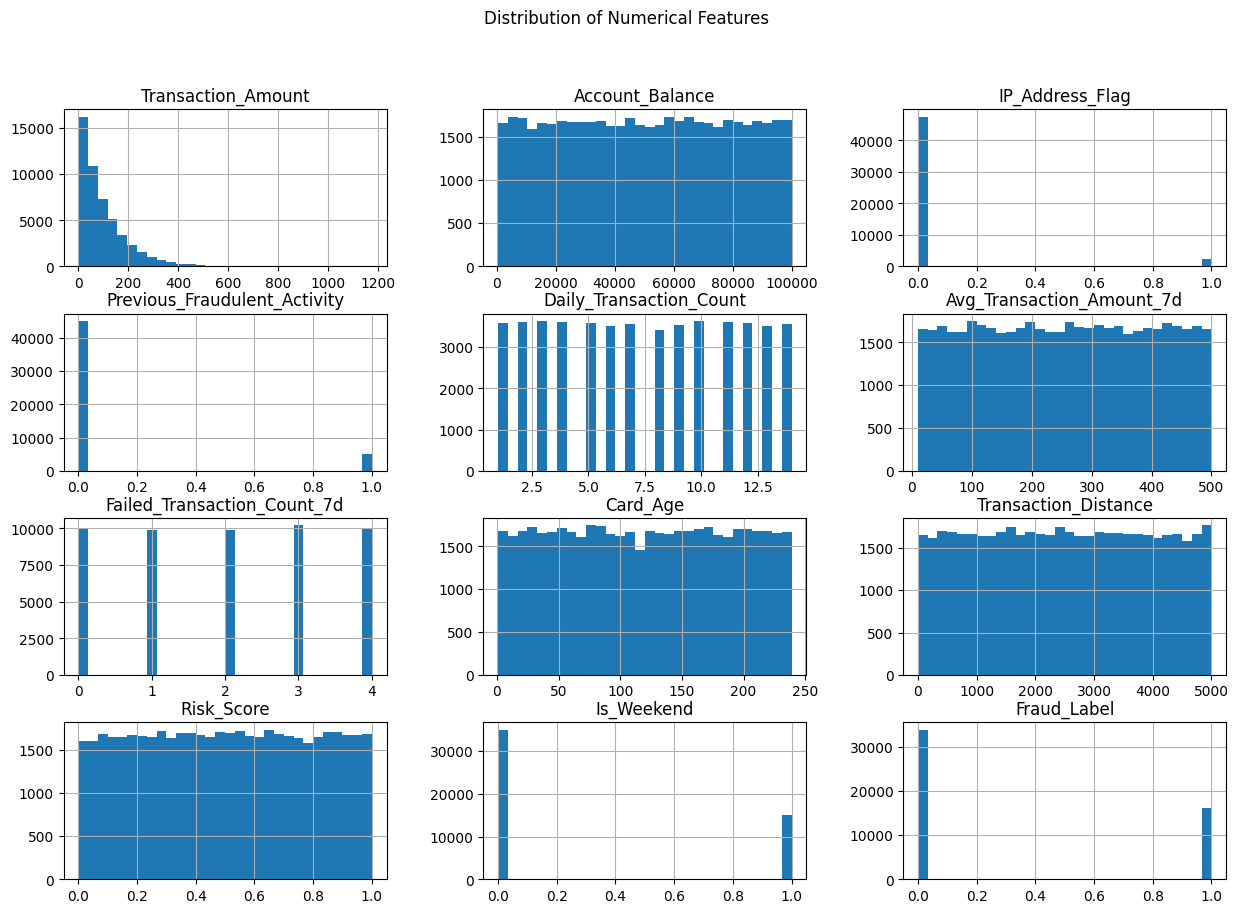

In [ ]:
# Histograms for numeric columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols].hist(figsize=(15,10), bins=30)
plt.suptitle("Distribution of Numerical Features")
plt.show()

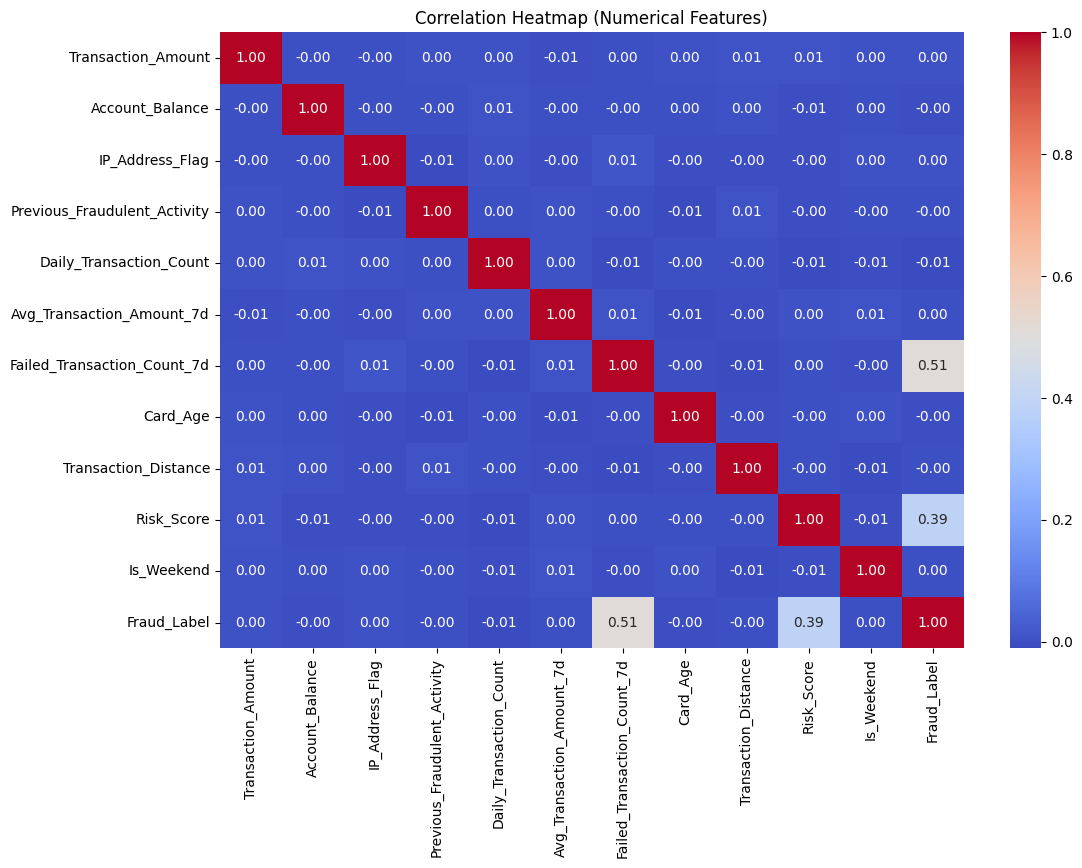

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(12,8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

In [ ]:
# ----------------- 1. Data Preprocessing -----------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Separate features & target
X = df.drop(columns=['Fraud_Label'])  # Change target column if needed
y = df['Fraud_Label']

# Drop rows with NaN in the target variable
nan_rows = y.isnull()
X = X[~nan_rows]
y = y[~nan_rows]


# Copy original features
X_original = X.copy()

# Identify numeric & categorical features
numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Define transformers
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))  # Sparse output for efficiency
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_original, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# Apply preprocessing
X_train_pre = preprocessor.fit_transform(X_train)  # Keep sparse
X_test_pre = preprocessor.transform(X_test)

print("Preprocessed Train Shape:", X_train_pre.shape)
print("Preprocessed Test Shape:", X_test_pre.shape)

Numeric features: ['Transaction_Amount', 'Account_Balance', 'IP_Address_Flag', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Age', 'Transaction_Distance', 'Risk_Score', 'Is_Weekend']
Categorical features: ['Transaction_ID', 'User_ID', 'Transaction_Type', 'Timestamp', 'Device_Type', 'Location', 'Merchant_Category', 'Merchant_UPI_ID', 'Card_Type', 'Authentication_Method']
Train shape: (40000, 21) Test shape: (10000, 21)
Preprocessed Train Shape: (40000, 110119)
Preprocessed Test Shape: (10000, 110119)


Original features: 110119
Reduced features: 50


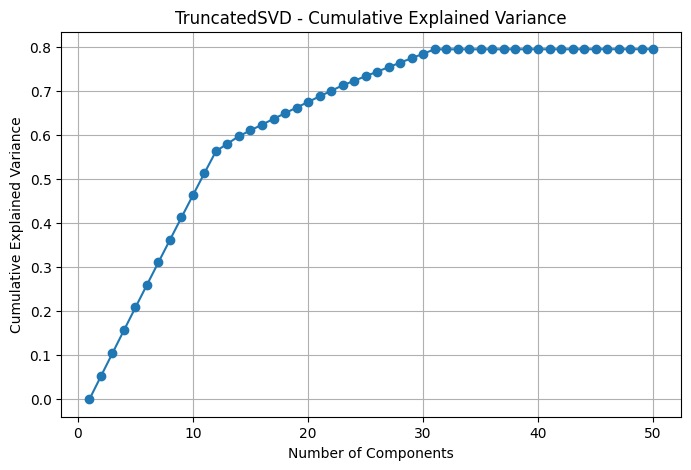

Explained Variance with 50 components: 79.55%


In [ ]:
# Dimensionality Reduction (TruncatedSVD)
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import numpy as np

# Assuming X_train_pre and X_test_pre are available from the preprocessing step.

# TruncatedSVD (PCA for sparse data)
n_components = 50   # Using 50 components as used previously
svd = TruncatedSVD(n_components=n_components, random_state=42)

X_train_pca = svd.fit_transform(X_train_pre)
X_test_pca = svd.transform(X_test_pre)

print("Original features:", X_train_pre.shape[1])
print("Reduced features:", X_train_pca.shape[1])

# Explained Variance
explained_var_ratio = svd.explained_variance_ratio_.cumsum()

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_var_ratio)+1), explained_var_ratio, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("TruncatedSVD - Cumulative Explained Variance")
plt.grid(True)
plt.show()

print(f"Explained Variance with {n_components} components: {explained_var_ratio[-1]:.2%}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


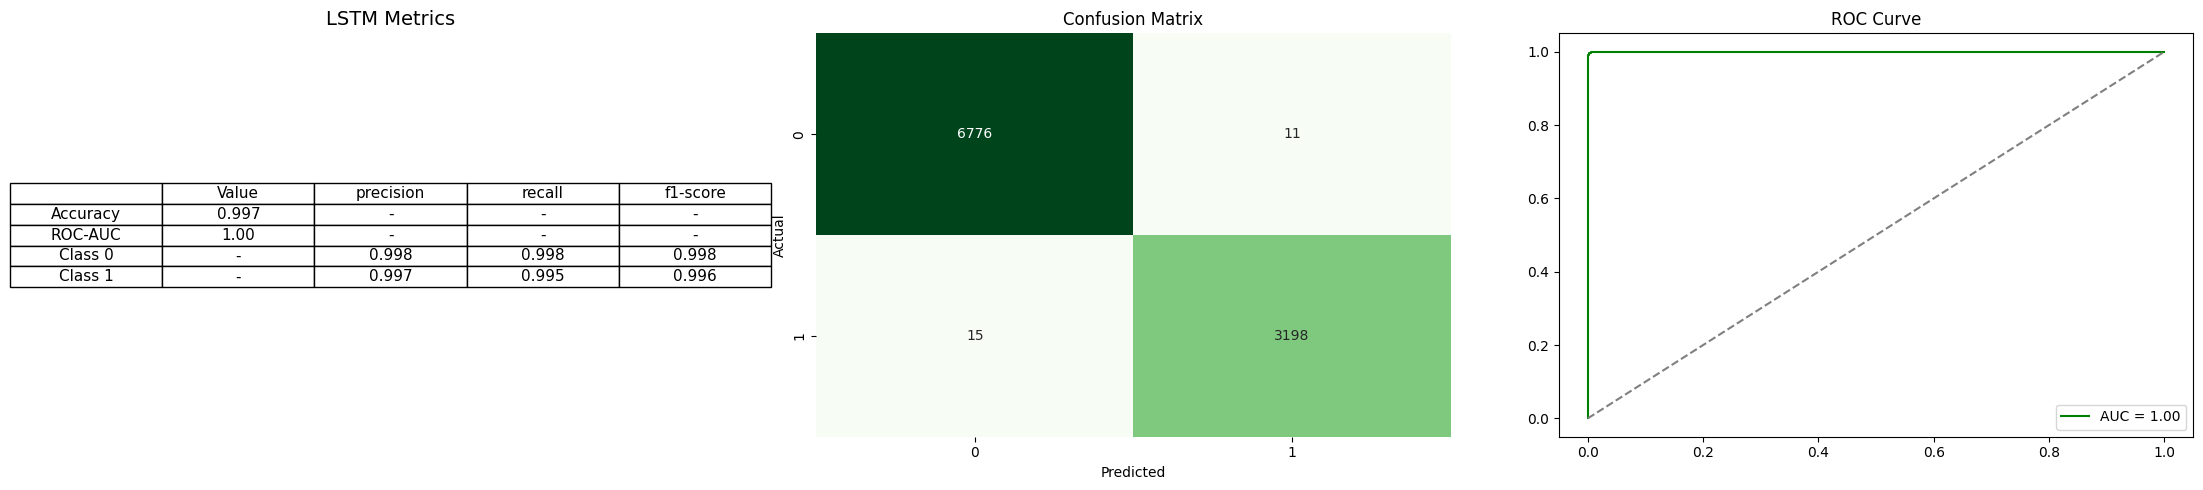

In [ ]:
# --- LSTM Evaluation ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Reshape
X_train_r = np.reshape(X_train_pca, (X_train_pca.shape[0], 1, X_train_pca.shape[1]))
X_test_r = np.reshape(X_test_pca, (X_test_pca.shape[0], 1, X_test_pca.shape[1]))

# Model
model_lstm = Sequential([
    LSTM(64, input_shape=(X_train_r.shape[1], X_train_r.shape[2]), return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm.fit(X_train_r, y_train, epochs=30, batch_size=64, verbose=0, validation_split=0.2)

# Predictions
y_prob_lstm = model_lstm.predict(X_test_r).ravel()
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)

# Metrics
accuracy = accuracy_score(y_test, y_pred_lstm)
roc_auc_val = roc_auc_score(y_test, y_prob_lstm)
report = classification_report(y_test, y_pred_lstm, output_dict=True, labels=[0, 1])

rows = [["Accuracy", f"{accuracy:.3f}", "-", "-", "-"],
        ["ROC-AUC", f"{roc_auc_val:.2f}", "-", "-", "-"]]
for label in ["0", "1"]:
    rows.append(["Class "+label, "-", f"{report[label]['precision']:.3f}",
                 f"{report[label]['recall']:.3f}", f"{report[label]['f1-score']:.3f}"])
columns = ["", "Value", "precision", "recall", "f1-score"]

cm = confusion_matrix(y_test, y_pred_lstm)
fpr, tpr, _ = roc_curve(y_test, y_prob_lstm)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(22,5))
axes[0].axis("off")
t = axes[0].table(cellText=rows, colLabels=columns, cellLoc="center", loc="center")
t.auto_set_font_size(False); t.set_fontsize(11); t.scale(1.2,1.2)
axes[0].set_title("LSTM Metrics", fontsize=14)

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[1])
axes[1].set_title("Confusion Matrix"); axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

axes[2].plot(fpr, tpr, color="green", label=f"AUC = {roc_auc_val:.2f}")
axes[2].plot([0,1],[0,1],"--",color="gray")
axes[2].set_title("ROC Curve"); axes[2].legend()
plt.tight_layout(); plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (64, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


 78/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


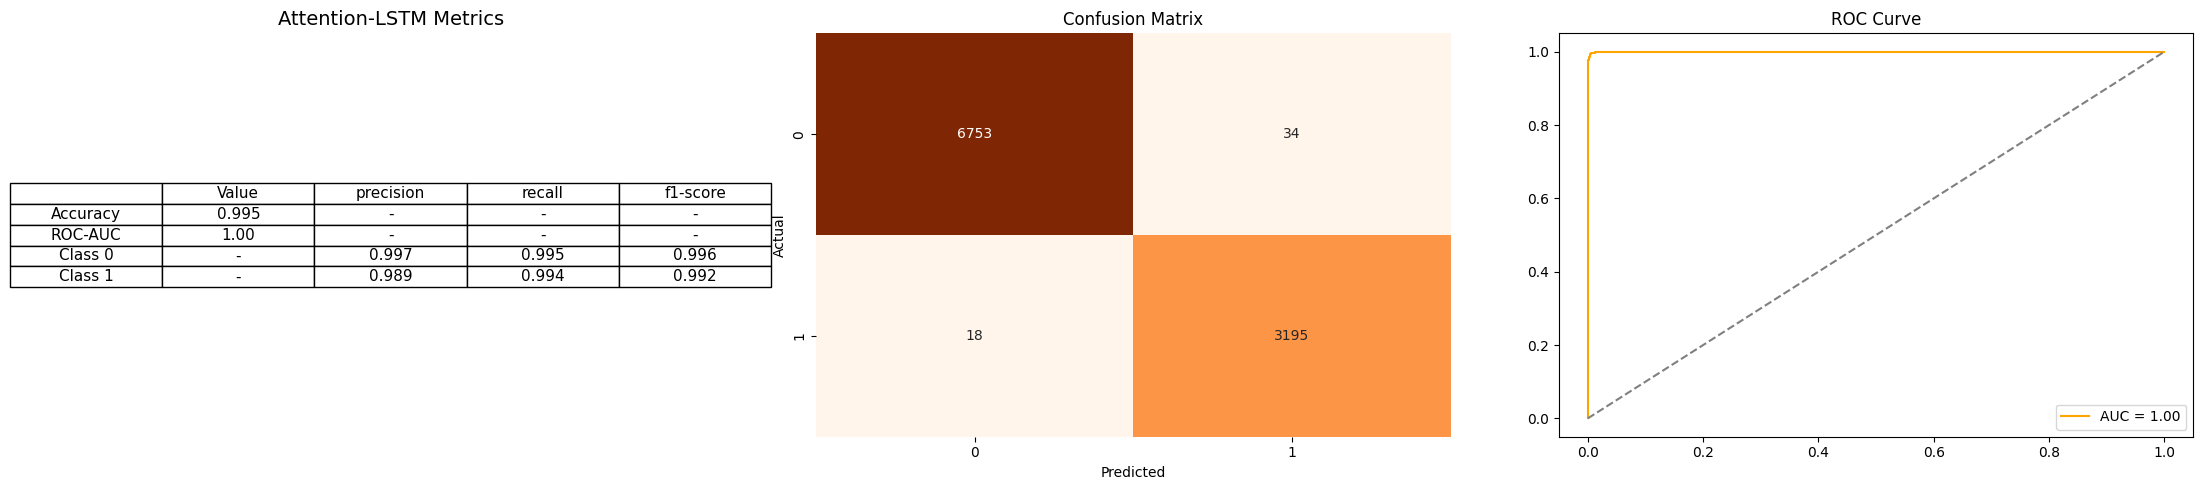

In [ ]:
# --- Attention LSTM Evaluation ---
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Attention, Flatten
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Reshape
X_train_r = np.reshape(X_train_pca, (X_train_pca.shape[0], 1, X_train_pca.shape[1]))
X_test_r = np.reshape(X_test_pca, (X_test_pca.shape[0], 1, X_test_pca.shape[1]))

# Model
inputs = Input(shape=(X_train_r.shape[1], X_train_r.shape[2]))
lstm_out = LSTM(64, return_sequences=True)(inputs)
attn_out = Attention()([lstm_out, lstm_out])
flat = Flatten()(attn_out)
dense = Dense(32, activation='relu')(flat)
drop = Dropout(0.3)(dense)
output = Dense(1, activation='sigmoid')(drop)

model_attn = Model(inputs, output)
model_attn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_attn.fit(X_train_r, y_train, epochs=30, batch_size=64, verbose=0, validation_split=0.2)

# Predictions
y_prob_attn = model_attn.predict(X_test_r).ravel()
y_pred_attn = (y_prob_attn > 0.5).astype(int)

# Metrics
accuracy = accuracy_score(y_test, y_pred_attn)
roc_auc_val = roc_auc_score(y_test, y_prob_attn)
report = classification_report(y_test, y_pred_attn, output_dict=True, labels=[0, 1])

rows = [["Accuracy", f"{accuracy:.3f}", "-", "-", "-"],
        ["ROC-AUC", f"{roc_auc_val:.2f}", "-", "-", "-"]]
for label in ["0", "1"]:
    rows.append(["Class "+label, "-", f"{report[label]['precision']:.3f}",
                 f"{report[label]['recall']:.3f}", f"{report[label]['f1-score']:.3f}"])
columns = ["", "Value", "precision", "recall", "f1-score"]

cm = confusion_matrix(y_test, y_pred_attn)
fpr, tpr, _ = roc_curve(y_test, y_prob_attn)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(22,5))
axes[0].axis("off")
t = axes[0].table(cellText=rows, colLabels=columns, cellLoc="center", loc="center")
t.auto_set_font_size(False); t.set_fontsize(11); t.scale(1.2,1.2)
axes[0].set_title("Attention-LSTM Metrics", fontsize=14)

sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", cbar=False, ax=axes[1])
axes[1].set_title("Confusion Matrix"); axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

axes[2].plot(fpr, tpr, color="orange", label=f"AUC = {roc_auc_val:.2f}")
axes[2].plot([0,1],[0,1],"--",color="gray")
axes[2].set_title("ROC Curve"); axes[2].legend()
plt.tight_layout(); plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


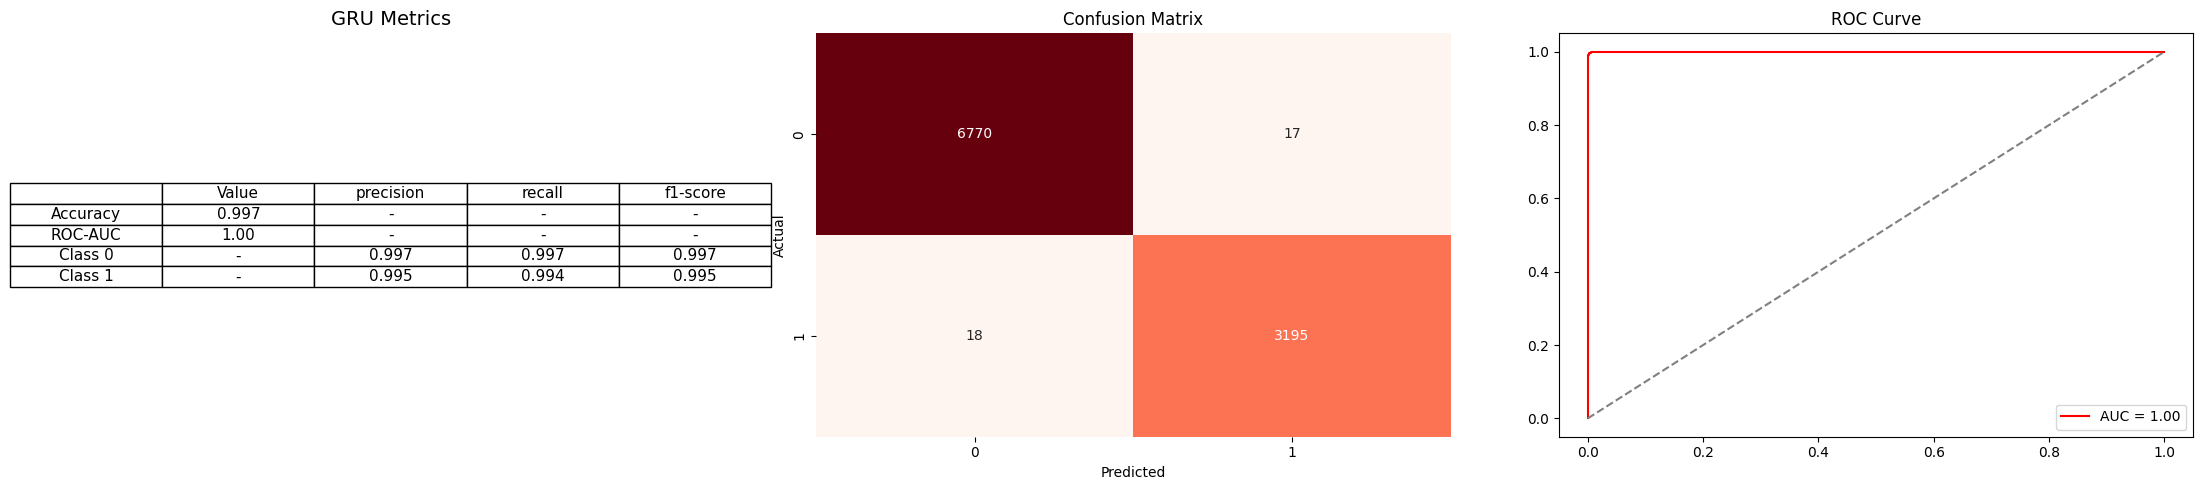

In [ ]:
# --- GRU Evaluation ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Reshape
X_train_r = np.reshape(X_train_pca, (X_train_pca.shape[0], 1, X_train_pca.shape[1]))
X_test_r = np.reshape(X_test_pca, (X_test_pca.shape[0], 1, X_test_pca.shape[1]))

# Model
model_gru = Sequential([
    GRU(64, input_shape=(X_train_r.shape[1], X_train_r.shape[2]), return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_gru.fit(X_train_r, y_train, epochs=30, batch_size=64, verbose=0, validation_split=0.2)

# Predictions
y_prob_gru = model_gru.predict(X_test_r).ravel()
y_pred_gru = (y_prob_gru > 0.5).astype(int)

# Metrics
accuracy = accuracy_score(y_test, y_pred_gru)
roc_auc_val = roc_auc_score(y_test, y_prob_gru)
report = classification_report(y_test, y_pred_gru, output_dict=True, labels=[0, 1])

rows = [["Accuracy", f"{accuracy:.3f}", "-", "-", "-"],
        ["ROC-AUC", f"{roc_auc_val:.2f}", "-", "-", "-"]]
for label in ["0", "1"]:
    rows.append(["Class "+label, "-", f"{report[label]['precision']:.3f}",
                 f"{report[label]['recall']:.3f}", f"{report[label]['f1-score']:.3f}"])
columns = ["", "Value", "precision", "recall", "f1-score"]

cm = confusion_matrix(y_test, y_pred_gru)
fpr, tpr, _ = roc_curve(y_test, y_prob_gru)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(22,5))
axes[0].axis("off")
t = axes[0].table(cellText=rows, colLabels=columns, cellLoc="center", loc="center")
t.auto_set_font_size(False); t.set_fontsize(11); t.scale(1.2,1.2)
axes[0].set_title("GRU Metrics", fontsize=14)

sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", cbar=False, ax=axes[1])
axes[1].set_title("Confusion Matrix"); axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

axes[2].plot(fpr, tpr, color="red", label=f"AUC = {roc_auc_val:.2f}")
axes[2].plot([0,1],[0,1],"--",color="gray")
axes[2].set_title("ROC Curve"); axes[2].legend()
plt.tight_layout(); plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
LSTM: Accuracy = 0.9966, ROC-AUC = 0.9999


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Attention-LSTM: Accuracy = 0.9940, ROC-AUC = 0.9999


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
GRU: Accuracy = 0.9966, ROC-AUC = 0.9999

--- Deep Learning Model Comparison ---
LSTM: Accuracy = 0.9966, ROC-AUC = 0.9999
Attention-LSTM: Accuracy = 0.9940, ROC-AUC = 0.9999
GRU: Accuracy = 0.9966, ROC-AUC = 0.9999


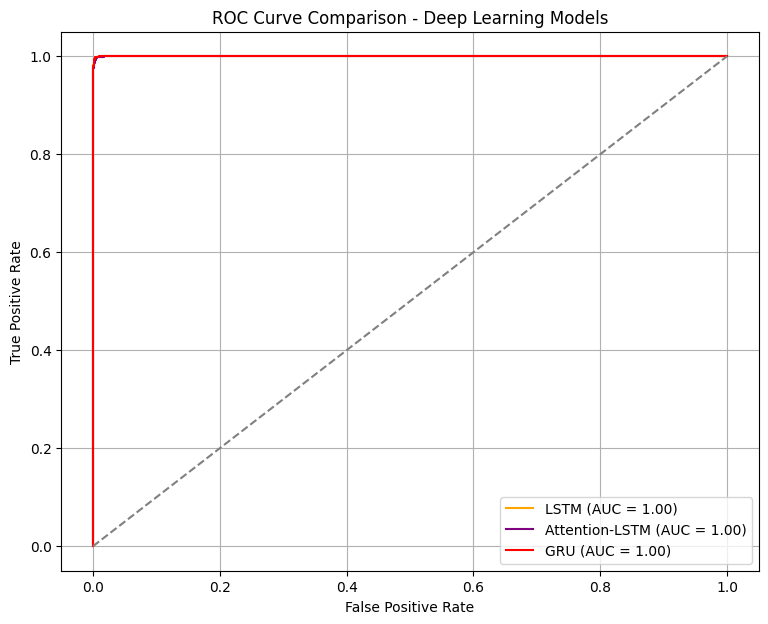

In [ ]:
# --- Deep Learning Model Comparison: LSTM, Attention-LSTM, GRU ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, LSTM, GRU, Input, Attention, Concatenate
from tensorflow.keras.optimizers import Adam

# Ensure y are numpy arrays
y_train = np.array(y_train)
y_test = np.array(y_test)

# If targets are not categorical (binary), reshape appropriately
if len(y_train.shape) == 1:
    y_train_bin = y_train
    y_test_bin = y_test
else:
    y_train_bin = y_train.argmax(axis=1)
    y_test_bin = y_test.argmax(axis=1)

results = {}
roc_curves = {}

# -------------------------
# Helper function to evaluate model
# -------------------------
def evaluate_dl_model(model, X_test, y_test, name):
    y_prob = model.predict(X_test).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    results[name] = (acc, roc)
    roc_curves[name] = (fpr, tpr, roc)
    print(f"{name}: Accuracy = {acc:.4f}, ROC-AUC = {roc:.4f}")
    return acc, roc


# ----------------------------------------------------
# Reshape input for sequence models (LSTM/GRU/Attention)
# ----------------------------------------------------
X_train_seq = np.expand_dims(X_train_pca, axis=1)
X_test_seq = np.expand_dims(X_test_pca, axis=1)


# ----------------------------------------------------
# 1️⃣ LSTM
# ----------------------------------------------------
lstm = Sequential([
    LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dense(1, activation='sigmoid')
])
lstm.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
lstm.fit(X_train_seq, y_train_bin, epochs=25, batch_size=32, verbose=0)
evaluate_dl_model(lstm, X_test_seq, y_test_bin, "LSTM")


# ----------------------------------------------------
# 2️⃣ Attention-LSTM
# ----------------------------------------------------
input_layer = Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2]))
lstm_out = LSTM(64, return_sequences=True)(input_layer)
attention = Attention()([lstm_out, lstm_out])  # self-attention
attn_concat = Concatenate()([lstm_out, attention])
dense_out = Dense(64, activation='relu')(attn_concat[:, -1, :])
output = Dense(1, activation='sigmoid')(dense_out)

attn_lstm = Model(inputs=input_layer, outputs=output)
attn_lstm.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
attn_lstm.fit(X_train_seq, y_train_bin, epochs=25, batch_size=32, verbose=0)
evaluate_dl_model(attn_lstm, X_test_seq, y_test_bin, "Attention-LSTM")


# ----------------------------------------------------
# 3️⃣ GRU
# ----------------------------------------------------
gru = Sequential([
    GRU(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dense(1, activation='sigmoid')
])
gru.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
gru.fit(X_train_seq, y_train_bin, epochs=25, batch_size=32, verbose=0)
evaluate_dl_model(gru, X_test_seq, y_test_bin, "GRU")


# ----------------------------------------------------
# Print Comparison Results
# ----------------------------------------------------
print("\n--- Deep Learning Model Comparison ---")
for model, (acc, roc) in results.items():
    print(f"{model}: Accuracy = {acc:.4f}, ROC-AUC = {roc:.4f}")


# ----------------------------------------------------
# Plot ROC Curves
# ----------------------------------------------------
plt.figure(figsize=(9,7))
colors = {
    "LSTM": "orange",
    "Attention-LSTM": "purple",
    "GRU": "red"
}

for model, (fpr, tpr, roc) in roc_curves.items():
    plt.plot(fpr, tpr, color=colors[model], label=f"{model} (AUC = {roc:.2f})")

plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.title("ROC Curve Comparison - Deep Learning Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()
